# DC test for SF
- Ch1 -- Vin
- Ch2 -- Vdd
- Ch3 -- Vbias

In [19]:
import numpy as np
import time
import matplotlib.pyplot as plt
from pytestlab import Bench

In [27]:
def run_vtc_plotter():
    print(f"Starting VTC Characterization...")
    # Storage for plotting: {v_bias: ([v_in_list], [v_out_list])}
    results = {}

    with Bench.open("bench.yaml") as bench:
        psu = bench.psu
        dmm = bench.dmm
        # --- 1. SETUP ---
        try:
            cmd = "CONF:VOLT:DC"
            if hasattr(dmm, "_write"): 
                dmm._write(cmd)
            elif hasattr(dmm, "write"): 
                dmm.write(cmd)
        except: pass

        v_bias_steps = np.arange(1.0, 3.6, 0.5) # Larger steps for clearer plot lines
        v_in_sweep = np.arange(0.0, 3.5, 0.05) # Finer resolution for smooth curves

        psu.set_voltage(2, 5.0) # VDD
        psu.output(2, True)
        # --- 2. LOOP & COLLECT ---
        for v_bias in v_bias_steps:
            print(f"Bumping V_bias to {v_bias}V...")

            v_in_vals = []
            v_out_vals = []

            psu.set_voltage(3, v_bias)
            psu.output(3, True)
            psu.output(1, True)

            for v_in in v_in_sweep:
                psu.set_voltage(1, v_in)
                time.sleep(0.1) # Short settle time
                try:
                    if hasattr(dmm, "_query"): 
                        raw = dmm._query("MEAS:VOLT:DC?")
                    else: 
                        raw = dmm.instrument.query("MEAS:VOLT:DC?")

                    val = float(str(raw).strip())

                except:
                    val = 0.0


                v_in_vals.append(v_in)
                v_out_vals.append(val)


            results[v_bias] = (v_in_vals, v_out_vals)



    # --- 3. PLOTTING ---
    plt.figure(figsize=(10, 6))
    for v_bias, (v_in, v_out) in results.items():
        plt.plot(v_in, v_out, marker = 'o', label=f"Vbias = {v_bias}V")

    plt.title("Transfer Characteristic")
    plt.xlabel("Input Voltage (V_in)")
    plt.ylabel("Output Voltage (V_out)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Save the plot automatically
    plt.savefig("vtc_plot_1.png")
    print("Plot saved as vtc_plot.png")
    
    plt.show()

Starting VTC Characterization...
Bumping V_bias to 1.0V...
Bumping V_bias to 1.5V...
Bumping V_bias to 2.0V...
Bumping V_bias to 2.5V...
Bumping V_bias to 3.0V...
Bumping V_bias to 3.5V...
Plot saved as vtc_plot.png


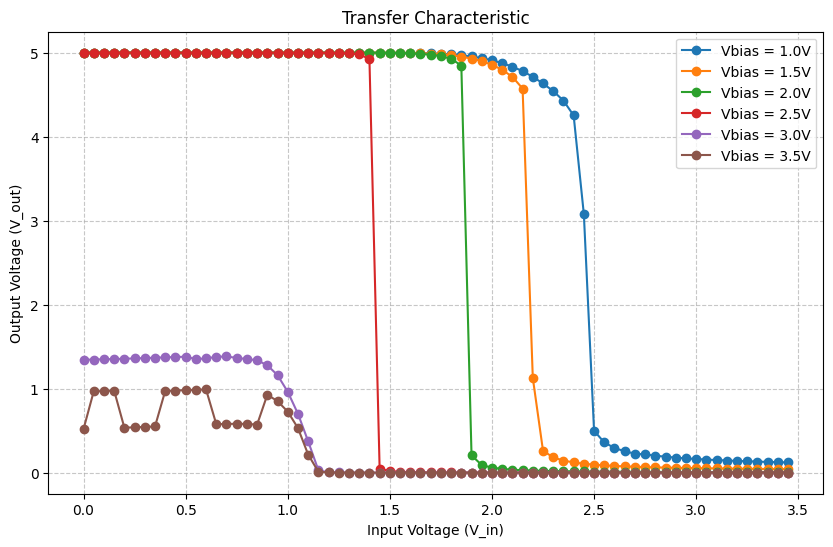

In [28]:
if __name__ == "__main__":
    run_vtc_plotter()